## Secondary neutrinos from UHECR propagation

1D simulation including secondary neutrinos from photopion production
and nuclear decay. Protons are injected from uniformly distributed
sources and propagated through the CMB and EBL. Hadrons and neutrinos
are stored separately using two observers.

**Note: the simulation might take a few minutes**

In [6]:
import subprocess, sys, os

# Install system dependencies
subprocess.run(['apt-get', 'install', '-qq', 'cmake', 'swig',
                'libhdf5-dev', 'zlib1g-dev', 'fftw3-dev'], check=True)

# Clone CRPropa3 only if not already present
if not os.path.exists('CRPropa3'):
    subprocess.run(['git', 'clone', '--depth=1',
                    'https://github.com/CRPropa/CRPropa3.git'], check=True)

os.makedirs('CRPropa3/build', exist_ok=True)
subprocess.run(['cmake', '..',
                '-DCMAKE_INSTALL_PREFIX=/usr/local',
                '-DENABLE_PYTHON=ON',
                '-DENABLE_HDF5=ON',
                '-DENABLE_OPENMP=OFF'],
               cwd='CRPropa3/build', check=True)
subprocess.run(['make', '-j2'], cwd='CRPropa3/build', check=True)
subprocess.run(['make', 'install'], cwd='CRPropa3/build', check=True)

sys.path.append('/usr/local/lib/python3/dist-packages')
from crpropa import *
import numpy as np
import matplotlib.pyplot as plt

print('✓ CRPropa3 ready')

✓ CRPropa3 ready


### Simulation setup

In [7]:
# simulation settings
neutrinos = True
photons   = False
electrons = False

cmb = CMB()
ebl = IRB_Gilmore12()

# module setup
m = ModuleList()
m.add(SimplePropagation(10 * kpc, 10 * Mpc))
m.add(Redshift())
m.add(PhotoPionProduction(cmb, photons, neutrinos))
m.add(PhotoPionProduction(ebl, photons, neutrinos))
m.add(NuclearDecay(electrons, photons, neutrinos))
m.add(ElectronPairProduction(cmb))
m.add(ElectronPairProduction(ebl))
m.add(MinimumEnergy(1e17 * eV))

# observer for hadrons
obs1 = Observer()
obs1.add(Observer1D())
obs1.add(ObserverNeutrinoVeto())
out1 = TextOutput('out_nucleons.txt', Output.Event1D)
out1.setEnergyScale(eV)
obs1.onDetection(out1)
m.add(obs1)

# observer for neutrinos
obs2 = Observer()
obs2.add(Observer1D())
obs2.add(ObserverNucleusVeto())
out2 = TextOutput('out_neutrinos.txt', Output.Event1D)
out2.setEnergyScale(eV)
obs2.onDetection(out2)
m.add(obs2)

# source: protons with power-law spectrum from uniformly distributed
# sources with redshift z = 0-3
source = Source()
source.add(SourceUniform1D(0, redshift2ComovingDistance(3)))
source.add(SourceRedshift1D())
source.add(SourcePowerLawSpectrum(1e17 * eV, 1e21 * eV, -1))
source.add(SourceParticleType(nucleusId(1, 1)))

# run simulation
m.setShowProgress(True)
m.run(source, 5000, True)

out1.close()
out2.close()

### Neutrino energy distribution

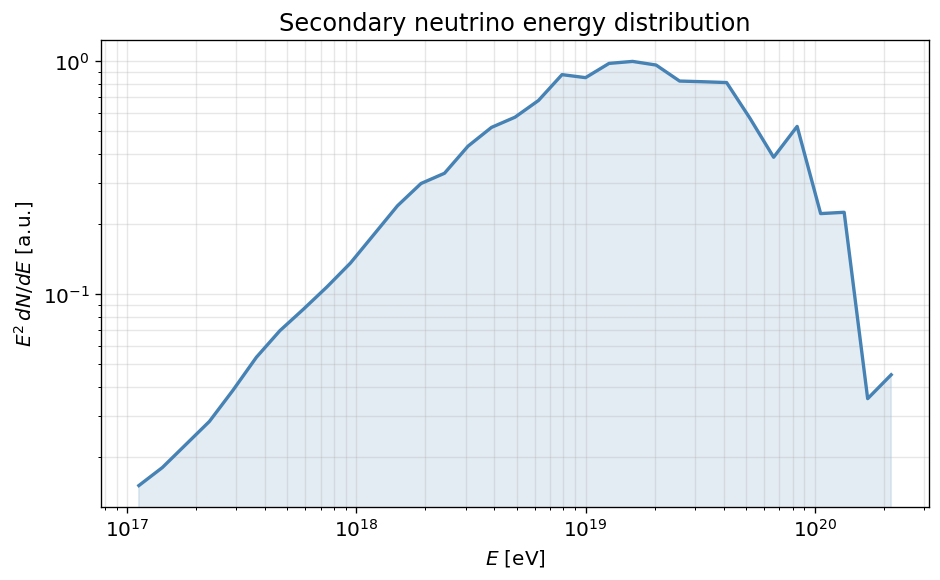

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

d = np.genfromtxt('out_neutrinos.txt', names=True)

# compute E² weighted flux
log_E_bins  = np.linspace(17, 21, 40)
E_centers   = 10**(0.5 * (log_E_bins[:-1] + log_E_bins[1:]))
delta_log_E = log_E_bins[1] - log_E_bins[0]
counts, _   = np.histogram(np.log10(d['E']), bins=log_E_bins)
flux        = E_centers**2 * counts / (E_centers * np.log(10) * delta_log_E)

plt.figure(figsize=(8, 5))
mask = flux > 0
plt.plot(E_centers[mask], flux[mask] / flux[mask].max(),
         color='steelblue', lw=2)
plt.fill_between(E_centers[mask], flux[mask] / flux[mask].max(),
                 alpha=0.15, color='steelblue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$E$ [eV]')
plt.ylabel(r'$E^2 \, dN/dE$ [a.u.]')
plt.title('Secondary neutrino energy distribution')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('neutrino_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

### Effect of source spectral index

Repeating the simulation with a softer injection spectrum (α = -2)
to show the effect on the secondary neutrino flux.

In [9]:
# simulation with soft spectral index α = -2
m2 = ModuleList()
m2.add(SimplePropagation(10 * kpc, 10 * Mpc))
m2.add(Redshift())
m2.add(PhotoPionProduction(cmb, photons, neutrinos))
m2.add(PhotoPionProduction(ebl, photons, neutrinos))
m2.add(NuclearDecay(electrons, photons, neutrinos))
m2.add(ElectronPairProduction(cmb))
m2.add(ElectronPairProduction(ebl))
m2.add(MinimumEnergy(1e17 * eV))

obs3 = Observer()
obs3.add(Observer1D())
obs3.add(ObserverNucleusVeto())
out3 = TextOutput('out_neutrinos_soft.txt', Output.Event1D)
out3.setEnergyScale(eV)
obs3.onDetection(out3)
m2.add(obs3)

source2 = Source()
source2.add(SourceUniform1D(0, redshift2ComovingDistance(3)))
source2.add(SourceRedshift1D())
source2.add(SourcePowerLawSpectrum(1e17 * eV, 1e21 * eV, -2))  # soft spectrum
source2.add(SourceParticleType(nucleusId(1, 1)))

m2.setShowProgress(True)
m2.run(source2, 5000, True)
out3.close()
print('✓ Done')

✓ Done


### Spectral index comparison

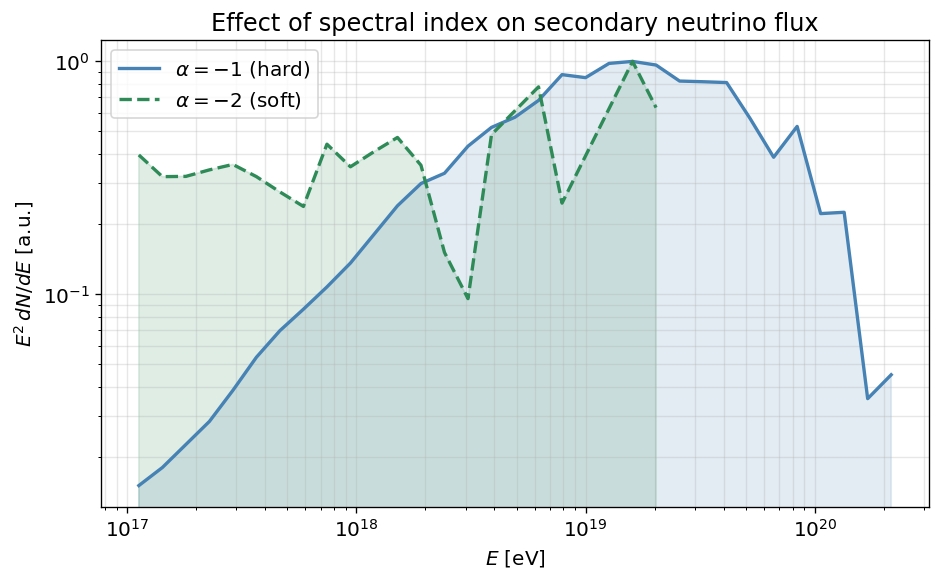

In [10]:
# load both outputs
d_hard = np.genfromtxt('out_neutrinos.txt',      names=True)
d_soft = np.genfromtxt('out_neutrinos_soft.txt', names=True)

def compute_flux(data, n_bins=40):
    log_E_bins  = np.linspace(17, 21, n_bins)
    E_centers   = 10**(0.5 * (log_E_bins[:-1] + log_E_bins[1:]))
    delta_log_E = log_E_bins[1] - log_E_bins[0]
    counts, _   = np.histogram(np.log10(data['E']), bins=log_E_bins)
    flux        = E_centers**2 * counts / (E_centers * np.log(10) * delta_log_E)
    return E_centers, flux / flux[flux > 0].max()

E_hard, flux_hard = compute_flux(d_hard)
E_soft, flux_soft = compute_flux(d_soft)

plt.figure(figsize=(8, 5))

mask_h = flux_hard > 0
mask_s = flux_soft > 0

plt.plot(E_hard[mask_h], flux_hard[mask_h],
         color='steelblue', lw=2, label=r'$\alpha = -1$ (hard)')
plt.fill_between(E_hard[mask_h], flux_hard[mask_h],
                 alpha=0.15, color='steelblue')

plt.plot(E_soft[mask_s], flux_soft[mask_s],
         color='seagreen', lw=2, ls='--', label=r'$\alpha = -2$ (soft)')
plt.fill_between(E_soft[mask_s], flux_soft[mask_s],
                 alpha=0.15, color='seagreen')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$E$ [eV]')
plt.ylabel(r'$E^2 \, dN/dE$ [a.u.]')
plt.title('Effect of spectral index on secondary neutrino flux')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('neutrino_spectrum_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The hard spectrum (α = -1) produces a smoother neutrino flux with more
particles reaching GZK threshold energies (~10¹⁹ eV). The soft spectrum
(α = -2) results in fewer high-energy primaries and a noisier distribution.
Increasing the number of simulated particles reduces the statistical noise.